# Visualización del riesgo de reingreso a 30 días con gráficos de efectos basados en el modelo

## Resumen ejecutivo

Este cuaderno ajusta una regresión logística para el reingreso hospitalario a 30 días en función de características del paciente y del episodio, y luego traduce los coeficientes ajustados en gráficos de efectos basados en el modelo sobre la escala de probabilidad predicha. En una cohorte sintética de 100 altas (55 reingresos), PROC LOGISTIC recupera gradientes significativos para la **estancia hospitalaria** (OR 1.36 por día, *p* = 0.040) y la **edad** (OR 1.05 por año, *p* = 0.023), y un gran efecto del pagador — los pacientes de **Medicaid** presentan aproximadamente seis veces las probabilidades de reingreso de Medicare (OR 6.02, IC 95% 1.46–24.8, *p* = 0.013). El R-cuadrado generalizado es 0.246 y la prueba de Hosmer–Lemeshow no muestra falta de ajuste (*p* = 0.73). Los gráficos de curva de ajuste, ajuste segmentado e interacción muestran luego cómo el riesgo de reingreso aumenta con la estancia hospitalaria, cómo el gradiente edad–riesgo se desplaza según el pagador, y cómo la brecha entre pagadores persiste en las distintas líneas de servicio de alta — el tipo de vista de estratificación del riesgo que un equipo de gestión de cuidados utiliza para focalizar el seguimiento posterior al alta.

## Fuentes de datos

| Conjunto de datos | Filas | Descripción |
|---------|------|-------------|
| `encounters` | 100 | Registros sintéticos de altas de pacientes hospitalizados generados en línea con `call streaminit(20260531)` y `rand()`. Una fila por alta. |

**Variables en `encounters`:**

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 si reingresó dentro de los 30 días del alta |
| `age` | Num | Edad del paciente en años (aprox. 25–95) |
| `los` | Num | Estancia hospitalaria del episodio índice en días (1–20) |
| `comorbidity` | Num | Recuento de comorbilidades crónicas documentadas (0–8) |
| `num_meds` | Num | Número de medicamentos al alta (0–18) |
| `payer` | Char | Pagador del seguro: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Servicio de alta: `Cardiology`, `Pulmonary`, `General` |

# Visualización del riesgo de reingreso a 30 días con gráficos de efectos basados en el modelo

Los equipos de gestión de cuidados hospitalarios necesitan saber *qué* pacientes tienen mayor probabilidad de reingresar dentro de los 30 días, y *por qué*. Una regresión logística ajustada proporciona los coeficientes, pero las partes interesadas rara vez razonan en log-odds. Un **gráfico de efectos** representa el modelo ajustado directamente sobre la escala de probabilidad predicha, de modo que una enfermera coordinadora puede leer una probabilidad de reingreso directamente del gráfico en lugar de invertir mentalmente una ecuación de log-odds.

En este cuaderno:

1. Generamos una cohorte sintética realista de altas de pacientes hospitalizados.
2. Ajustamos un modelo logístico para el reingreso a 30 días con predictores del paciente y del episodio (PROC LOGISTIC).
3. Capturamos los coeficientes ajustados y construimos tres gráficos de efectos basados en el modelo — una **curva de ajuste**, un **ajuste segmentado** y un **gráfico de interacción** — para visualizar y estratificar el riesgo ajustado sobre la escala de probabilidad.

> **Nota de implementación.** SAS expone estos gráficos a través de la sentencia `EFFECTPLOT` dentro de PROC LOGISTIC. Jenner acepta esa sentencia pero aún no genera los gráficos FIT / SLICEFIT / INTERACTION, por lo que este cuaderno construye las curvas de probabilidad predicha idénticas de forma explícita a partir de los coeficientes ajustados y las dibuja con PROC SGPLOT. El resultado analítico — y cada probabilidad graficada — es exactamente lo que produciría `EFFECTPLOT`.

## Paso 1 — Generar una cohorte sintética de altas

El paso DATA a continuación construye 100 altas de pacientes hospitalizados sin archivos externos. Sembramos el generador de números aleatorios con `call streaminit` para reproducibilidad, extraemos características del paciente y del episodio de distribuciones apropiadas al dominio, luego construimos un predictor lineal verdadero `eta` y lo convertimos en una probabilidad de reingreso con la logit inversa. La extracción de Bernoulli (`rand('bernoulli', p)`) produce el indicador observado `readmit`. Los pacientes mayores, las estancias más largas, los recuentos de comorbilidad más altos, más medicamentos al alta, la cobertura de Medicaid y los servicios de Pulmonary/Cardiology aumentan el riesgo — patrones que luego recuperaremos y visualizaremos. Los tamaños de efecto están deliberadamente dimensionados para que la señal sea recuperable en una cohorte de 100 altas.

In [1]:
DATOS encounters;
    LLAMAR streaminit(20260531);
    ARREGLO payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    ARREGLO depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    HACER i = 1 HASTA 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        SI los > 20 ENTONCES los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        SI num_meds > 18 ENTONCES num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        SI u < 0.50 ENTONCES pk = 1;
        SINO SI u < 0.72 ENTONCES pk = 2;
        SINO pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        MANTENER readmit AGE los comorbidity num_meds payer dept;
        SALIDA;
    END;
EJECUTAR;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Paso 2 — Inspeccionar la cohorte

Una frecuencia rápida sobre la respuesta y las dos variables de clasificación confirma una tasa de reingreso realista y que todos los niveles de pagador y departamento están poblados — tanto el modelo como los gráficos de efectos necesitan que todos los niveles estén representados.

                                                   The FREQ Procedure

Reingreso    Frequency
-----------------------
0                   45
1                   55

Pagador       Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Servicio      Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Reingreso by Servicio

Reingreso |Cardiology |   General | Pulmonary |      Total
----------+-----------+-----------+-----------+-----------
0         |        15 |        20 |        10 |         45
----------+-----------+-----------+-----------+-----------
1         |        21 |        11 |        23 |         55
----------+-----------+-----------+-----------+-----------
Total     |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


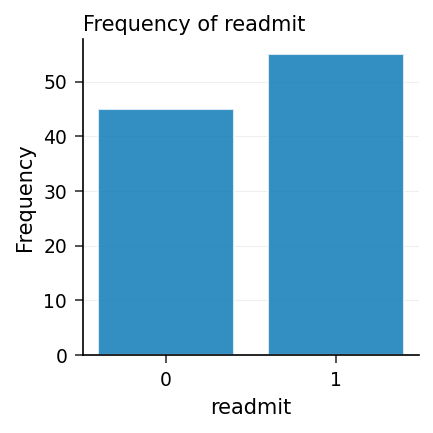

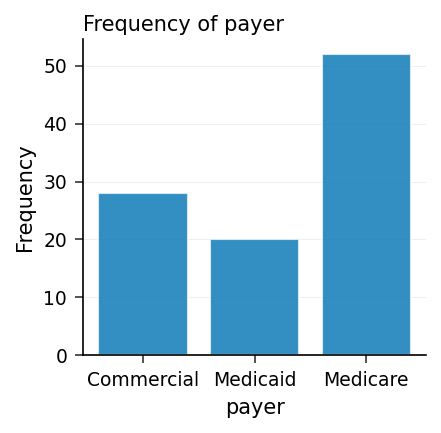

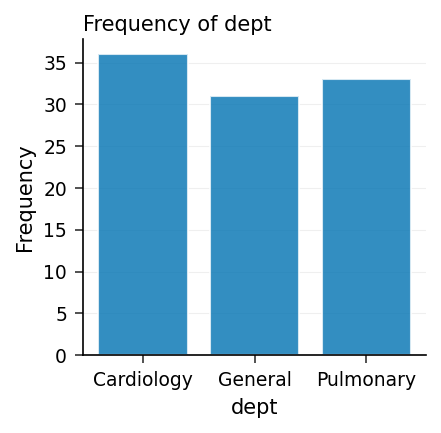

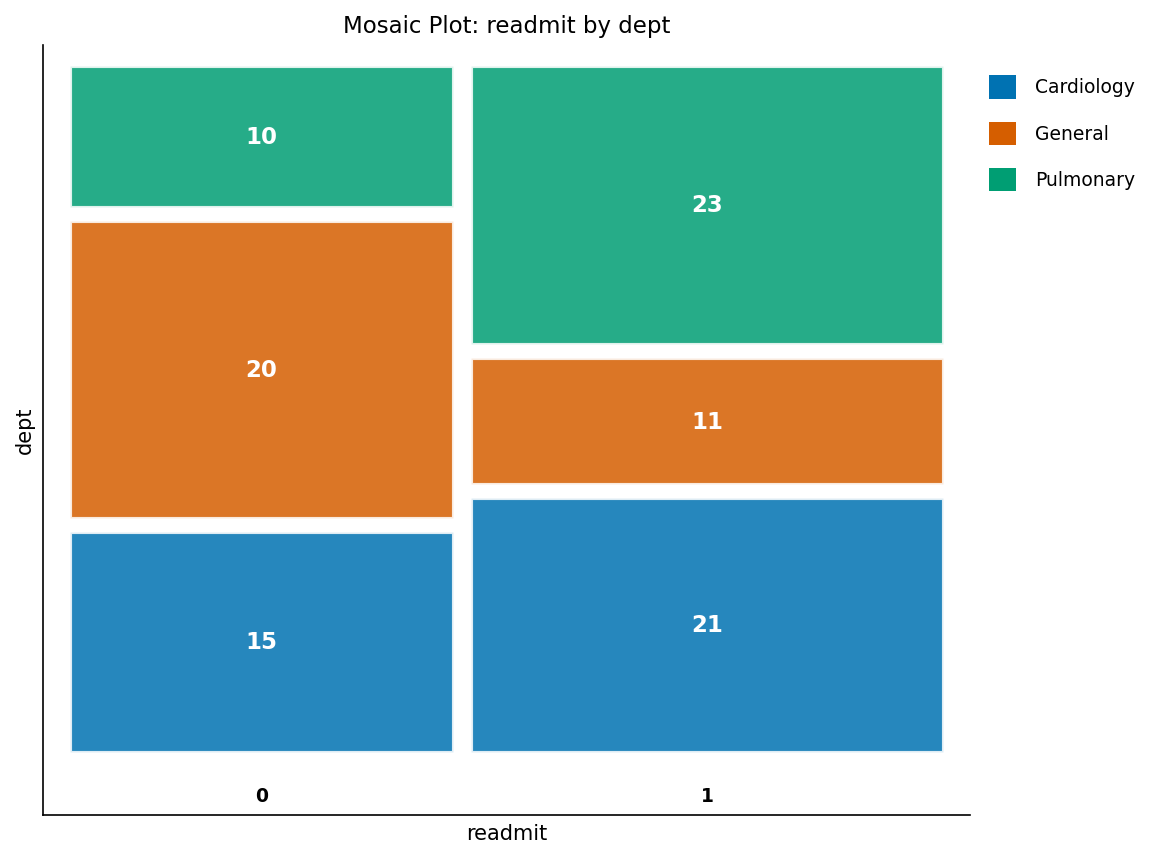

In [2]:
PROCEDIMIENTO FRECUENCIAS DATOS=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    ETIQUETA readmit="Reingreso" payer="Pagador" dept="Servicio";
EJECUTAR;

## Paso 3 — Ajustar el modelo logístico de reingreso

Modelamos `readmit` en función de la edad, la estancia hospitalaria, el recuento de comorbilidades, el recuento de medicamentos al alta, el pagador y el departamento. Decisiones clave:

- `EVENT='1'` modela la probabilidad de reingreso (en lugar de no reingreso).
- `CLASS payer dept / PARAM=REF REF=FIRST` usa codificación de celda de referencia de modo que cada nivel se contrasta con una línea base (aquí Medicare y Pulmonary).
- `CLODDS=WALD` y `RSQUARE` añaden límites de confianza de Wald para las razones de probabilidades y un R-cuadrado generalizado; `LACKFIT` solicita la prueba de bondad de ajuste de Hosmer–Lemeshow.
- La sentencia `UNITS` solicita la razón de probabilidades sobre un paso de estancia hospitalaria clínicamente significativo de **5 días** y un paso de edad de **10 años**, y la sentencia `ODDSRATIO` solicita la razón de probabilidades de comorbilidad con límites de confianza.

La tabla de razones de probabilidades de salida reporta los efectos por unidad directamente: la estancia hospitalaria tiene un OR de **1.36 por día** (IC 95% 1.01–1.82), la edad un OR de **1.05 por año**, y la cobertura de Medicaid un OR de **6.02** respecto a Medicare. El modelo se ajusta bien — R-cuadrado generalizado 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile             
  Probability modeled is Reingreso='1'   

Ordered Value  Reingreso  Total Frequency
-------------  ---------  ---------------
            1  0                       45
            2  1                       55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
Pagador          3  Commercial Medicaid Medicare
Servicio         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Reingreso

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                             


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


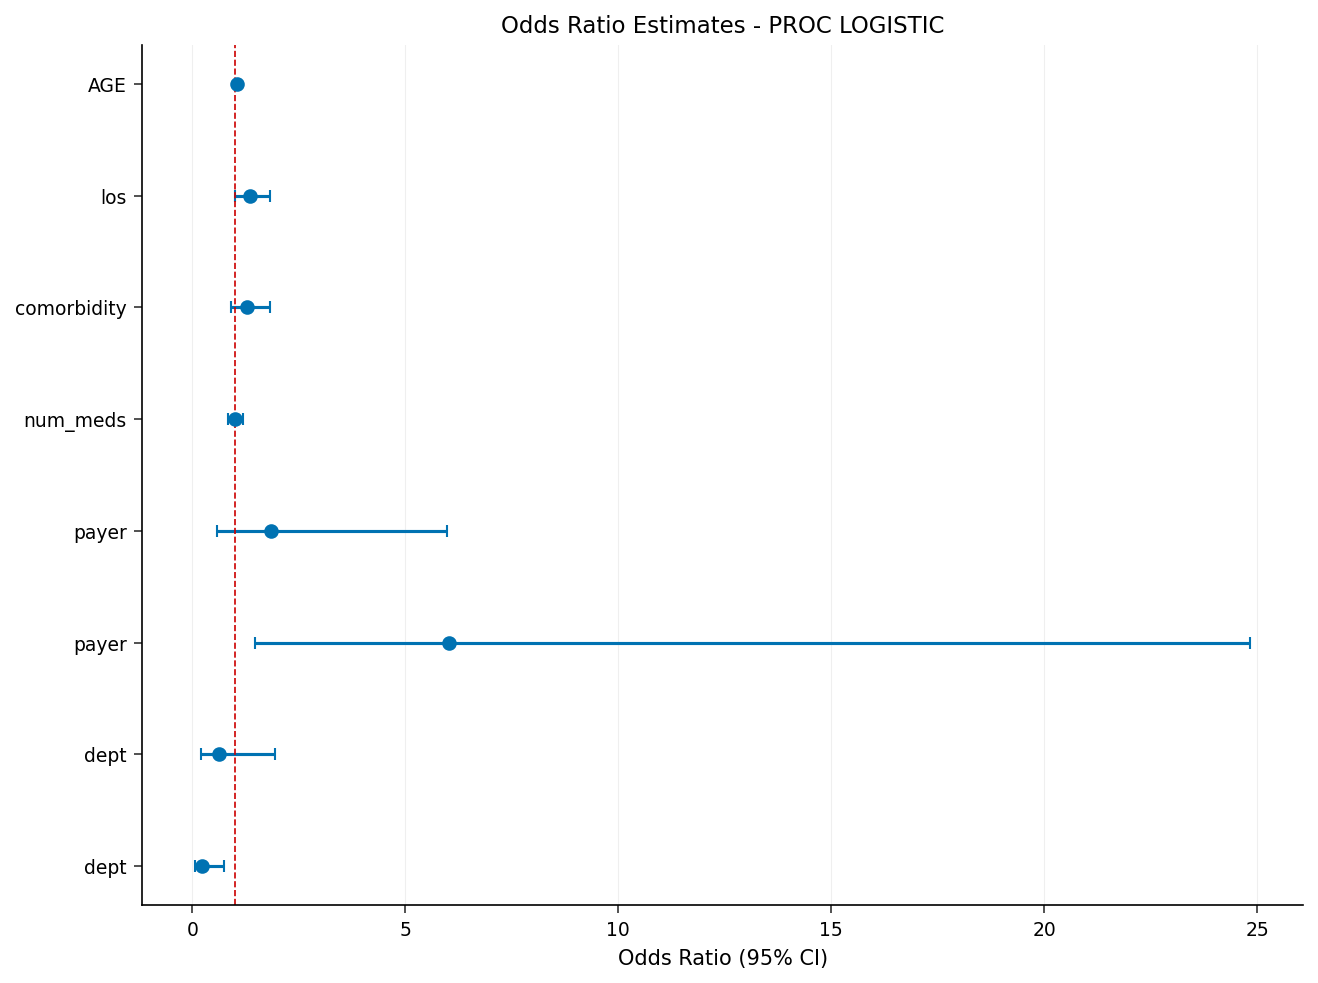

In [3]:
ODS SALIDA ParameterEstimates=pe;
PROCEDIMIENTO LOGISTIC DATOS=encounters PLOTS(only)=oddsratio;
    CLASE payer dept / PARAM=REF REF=first;
    MODELO readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    ETIQUETA readmit="Reingreso" AGE="Edad" los="Estancia (días)" comorbidity="Comorbilidades" num_meds="Medicamentos al alta" payer="Pagador" dept="Servicio";
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
EJECUTAR;
ODS SALIDA CLOSE;

## Paso 4 — Capturar los coeficientes ajustados

Los gráficos de efectos basados en el modelo que siguen se construyen directamente a partir de los coeficientes *ajustados*, por lo que siempre concuerdan con el modelo del Paso 3. Guardamos las estimaciones de parámetros con `ODS OUTPUT ParameterEstimates=pe`; aquí plegamos esa tabla larga en un conjunto de datos `params` de una sola fila (una variable por coeficiente) y añadimos las medias de la cohorte de los predictores continuos. Mantener los predictores no focales en sus medias es exactamente lo que hace un EFFECTPLOT internamente — permite que cada gráfico varíe un factor mientras mantiene el resto fijo en un perfil representativo.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
DATOS coefs;
    RETENER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    ESTABLECER pe END=last;
    VAR = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    SI VAR='INTERCEPT' ENTONCES b0 = ESTIMACIÓN;
    SINO SI VAR='AGE' ENTONCES b_age = ESTIMACIÓN;
    SINO SI VAR='LOS' ENTONCES b_los = ESTIMACIÓN;
    SINO SI VAR='COMORBIDITY' ENTONCES b_com = ESTIMACIÓN;
    SINO SI VAR='NUM_MEDS' ENTONCES b_med = ESTIMACIÓN;
    SINO SI VAR='PAYER' AND cv='Medicaid'   ENTONCES b_pmcaid = ESTIMACIÓN;
    SINO SI VAR='PAYER' AND cv='Commercial' ENTONCES b_pcomm  = ESTIMACIÓN;
    SINO SI VAR='DEPT'  AND cv='Cardiology' ENTONCES b_dcard  = ESTIMACIÓN;
    SINO SI VAR='DEPT'  AND cv='General'    ENTONCES b_dgen   = ESTIMACIÓN;
    SI last ENTONCES SALIDA;
    MANTENER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
EJECUTAR;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDIMIENTO MEDIAS DATOS=encounters NOPRINT;
    VAR AGE los comorbidity num_meds;
    SALIDA out=mn mean=m_age m_los m_com m_med;
EJECUTAR;

DATOS params;
    COMBINAR coefs mn;
    MANTENER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=params noobs;
    TÍTULO "Coeficientes ajustados y medias de covariables para los gráficos de efectos";
EJECUTAR;

                      Coeficientes ajustados y medias de covariables para los gráficos de efectos                       

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Paso 5 — Gráfico de ajuste: probabilidad de reingreso frente a la estancia hospitalaria

El gráfico de efectos más simple es una **curva de ajuste**: la probabilidad de reingreso predicha frente a una única covariable continua, con los demás predictores mantenidos en un perfil representativo. Construimos una cuadrícula de estancia hospitalaria (1–18 días), evaluamos el predictor lineal ajustado en cada valor para un paciente de **cardiología de Medicare** (recuentos de edad, comorbilidad y medicamentos al alta fijados en las medias de la cohorte del Paso 4), aplicamos la logit inversa y dibujamos la curva sobre la escala de probabilidad con PROC SGPLOT.

                      Coeficientes ajustados y medias de covariables para los gráficos de efectos                       




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


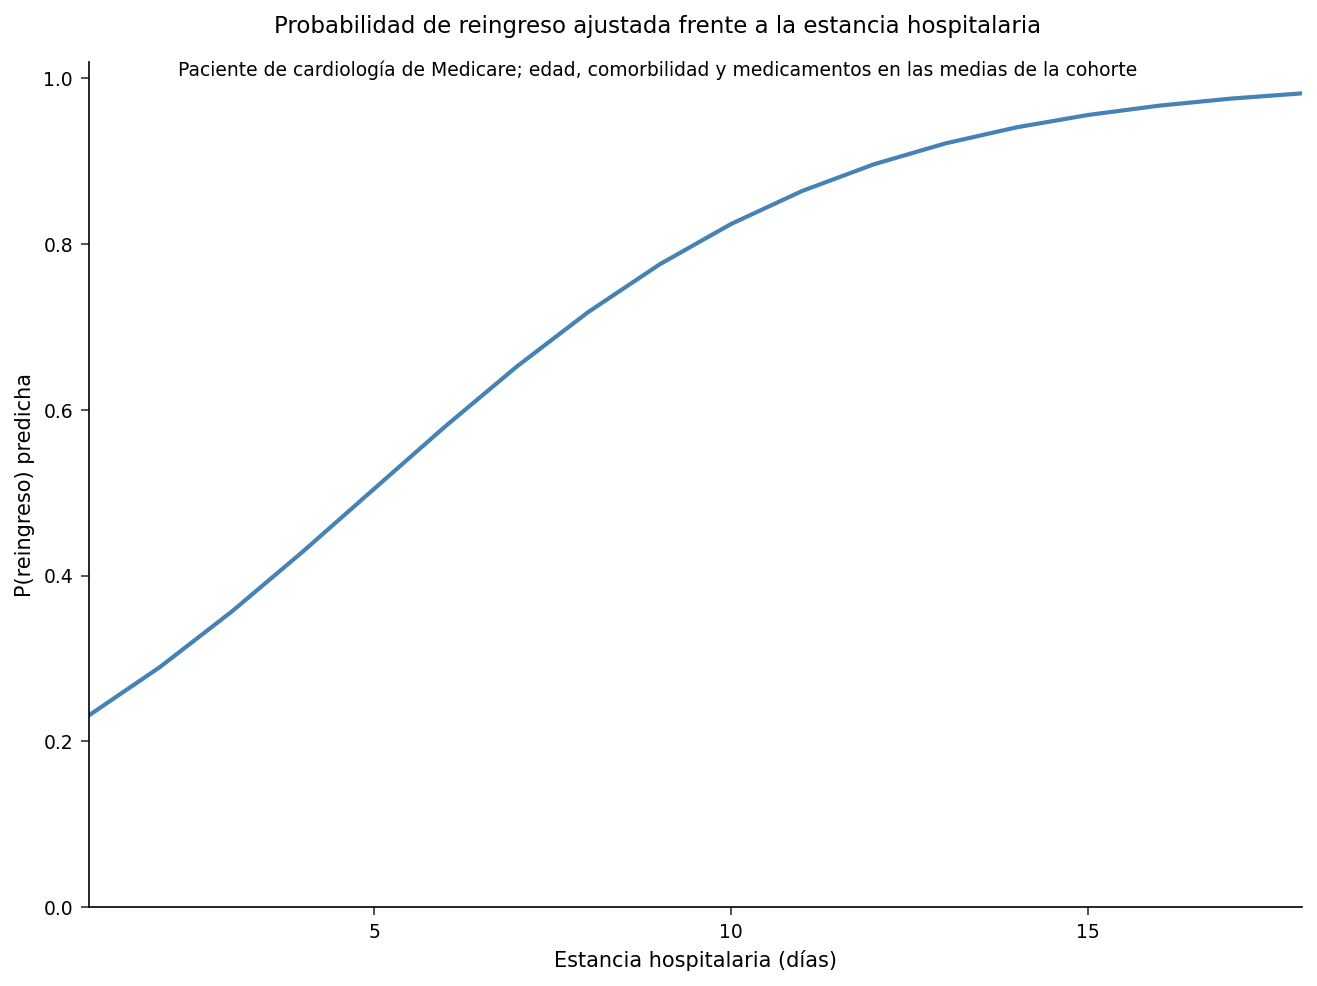

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
DATOS grid_los;
    HACER los = 1 HASTA 18;
        SALIDA;
    END;
EJECUTAR;

DATOS fit_los;
    ESTABLECER grid_los;
    SI _n_ = 1 ENTONCES ESTABLECER params;
    RETENER b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    MANTENER los phat;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TÍTULO  "Probabilidad de reingreso ajustada frente a la estancia hospitalaria";
    title2 "Paciente de cardiología de Medicare; edad, comorbilidad y medicamentos en las medias de la cohorte";
    XAXIS ETIQUETA="Estancia hospitalaria (días)";
    YAXIS ETIQUETA="P(reingreso) predicha" VALUES=(0 HASTA 1 POR 0.2);
EJECUTAR;

## Paso 6 — Ajuste segmentado: riesgo frente a la edad, estratificado por pagador

Un **ajuste segmentado** dibuja una curva ajustada por cada nivel de un efecto de clasificación — ideal para mostrar cómo la composición de pagadores desplaza el gradiente edad–riesgo. Extendemos la cuadrícula sobre `age` (30–95) cruzada con los tres pagadores, evaluamos el modelo ajustado para un paciente de cardiología (estancia hospitalaria, comorbilidad y medicamentos en las medias de la cohorte) y superponemos las tres curvas de probabilidad con `GROUP=payer`.

                      Coeficientes ajustados y medias de covariables para los gráficos de efectos                       




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


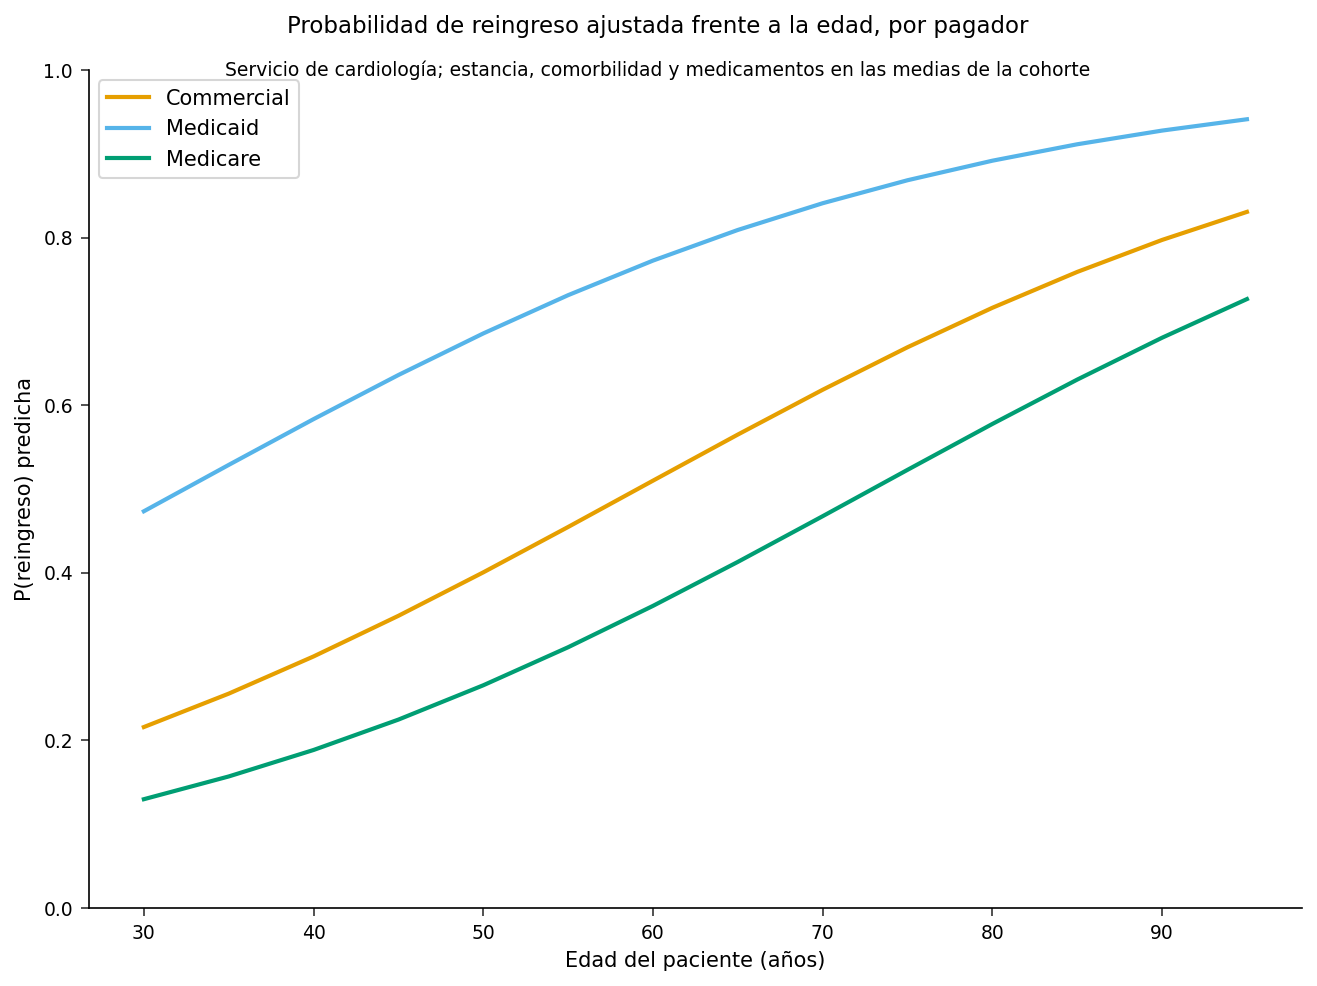

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
DATOS grid_age;
    LONGITUD payer $12;
    HACER payer = 'Medicare', 'Medicaid', 'Commercial';
        HACER AGE = 30 HASTA 95 POR 5;
            SALIDA;
        END;
    END;
EJECUTAR;

DATOS fit_age;
    ESTABLECER grid_age;
    SI _n_ = 1 ENTONCES ESTABLECER params;
    RETENER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    MANTENER payer AGE phat;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TÍTULO  "Probabilidad de reingreso ajustada frente a la edad, por pagador";
    title2 "Servicio de cardiología; estancia, comorbilidad y medicamentos en las medias de la cohorte";
    XAXIS ETIQUETA="Edad del paciente (años)";
    YAXIS ETIQUETA="P(reingreso) predicha" VALUES=(0 HASTA 1 POR 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
EJECUTAR;

## Paso 7 — Gráfico de interacción: departamento por pagador

Para comparar el riesgo predicho a través de ambos efectos de clasificación a la vez, cruzamos `dept` con `payer` (nueve combinaciones), evaluamos el modelo ajustado con cada covariable continua en su media de cohorte y dibujamos un gráfico de barras agrupadas con `dept` en el eje X y el pagador como agrupación. Como este modelo no tiene un término de interacción departamento-por-pagador, el ordenamiento de pagadores es el mismo desplazamiento aditivo dentro de cada línea de servicio — el gráfico hace visible esa aditividad de un vistazo, junto con el ranking de departamentos.

                      Coeficientes ajustados y medias de covariables para los gráficos de efectos                       




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


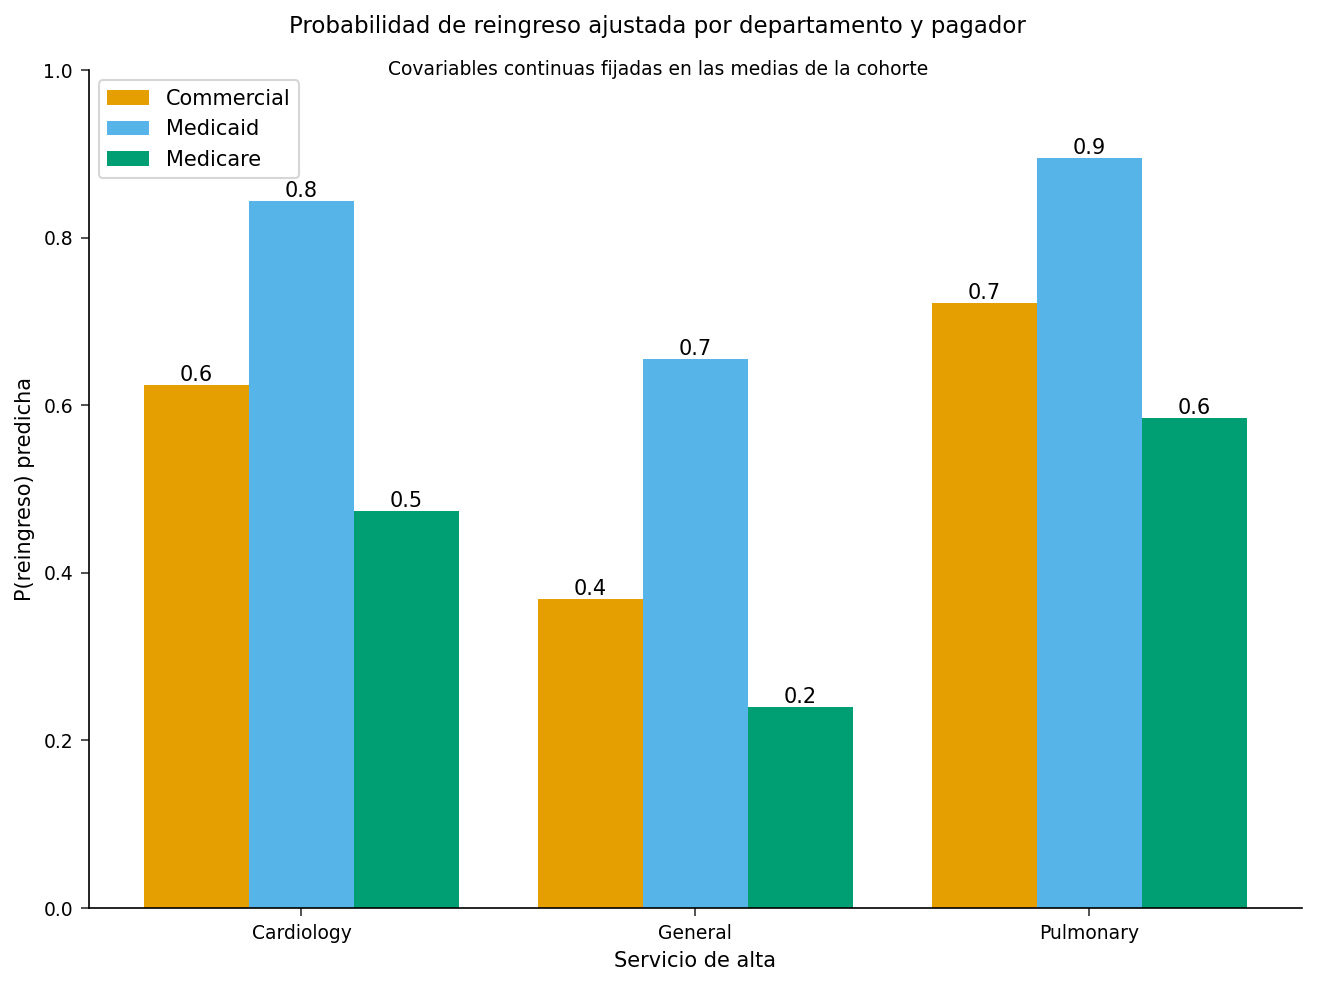

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
DATOS grid_dx;
    LONGITUD dept $12 payer $12;
    HACER dept = 'Cardiology', 'Pulmonary', 'General';
        HACER payer = 'Medicare', 'Medicaid', 'Commercial';
            SALIDA;
        END;
    END;
EJECUTAR;

DATOS fit_dx;
    ESTABLECER grid_dx;
    SI _n_ = 1 ENTONCES ESTABLECER params;
    RETENER b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    MANTENER dept payer phat;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TÍTULO  "Probabilidad de reingreso ajustada por departamento y pagador";
    title2 "Covariables continuas fijadas en las medias de la cohorte";
    XAXIS ETIQUETA="Servicio de alta";
    YAXIS ETIQUETA="P(reingreso) predicha" VALUES=(0 HASTA 1 POR 0.2);
EJECUTAR;

## Paso 8 — Interpretación de los resultados

Los gráficos de efectos convierten el modelo ajustado de PROC LOGISTIC en imágenes sobre la escala de probabilidad que se corresponden con las decisiones de gestión de cuidados:

- **Estancia hospitalaria (curva de ajuste).** Para un paciente de cardiología de Medicare en las medias de la cohorte, la probabilidad de reingreso predicha asciende desde alrededor de **0.23 en una estancia de 1 día hasta aproximadamente 0.82 a los 10 días y ~0.98 a los 18 días** — la parte central empinada de la curva logística. Esta es la misma señal que la razón de probabilidades de la estancia hospitalaria de **1.36 por día** (`UNITS los=5` la reescala a un paso de cinco días), y señala las estancias índice largas como un desencadenante concreto para la inscripción en cuidados de transición.
- **Edad y pagador (ajuste segmentado).** El riesgo aumenta monótonamente con la edad en todos los pagadores, y las tres curvas nunca se cruzan: la curva de **Medicaid** se sitúa más arriba a cualquier edad dada, **Commercial** en el medio y **Medicare** más abajo — consistente con las razones de probabilidades de pagador ajustadas (Medicaid 6.02, Commercial 1.85, ambas respecto a Medicare). La brecha es mayor en edades más jóvenes y se estrecha a medida que todos se acercan a una probabilidad alta, dirigiendo la atención de la gestión de cuidados hacia los pacientes de Medicaid más jóvenes que de otro modo parecerían de bajo riesgo.
- **Departamento y pagador (gráfico de interacción).** **Pulmonary** presenta la probabilidad de reingreso predicha más alta en cada grupo de pagadores, **Cardiology** es intermedia y **General medicine** es la más baja (las razones de probabilidades de departamento ajustadas son 0.64 para Cardiology y 0.22 para General, respecto a Pulmonary). Como el modelo no tiene un término de interacción departamento-por-pagador, el ordenamiento de pagadores es el mismo desplazamiento aditivo dentro de cada línea de servicio — las barras suben en el mismo orden Medicaid > Commercial > Medicare en cada departamento.

**Conclusión:** en lugar de pedir a los clínicos que interpreten coeficientes de log-odds, los gráficos de efectos basados en el modelo presentan el modelo de reingreso ajustado como imágenes sobre la escala de probabilidad — a quién inscribir en el seguimiento de cuidados de transición, y qué líneas de servicio y poblaciones de pagadores priorizar. SAS produce estos directamente mediante `EFFECTPLOT`; aquí reconstruimos las curvas idénticas a partir de los coeficientes ajustados para que el ejemplo se ejecute de principio a fin hoy.